In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

daily = pd.read_csv('../data/daily_sales.csv', parse_dates=['Date'])
daily.set_index('Date', inplace=True)

# ADF test for stationarity
result = adfuller(daily['Revenue'].dropna())
print(f'ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
# p < 0.05 means stationary

ADF Statistic: -0.3661, p-value: 0.9156


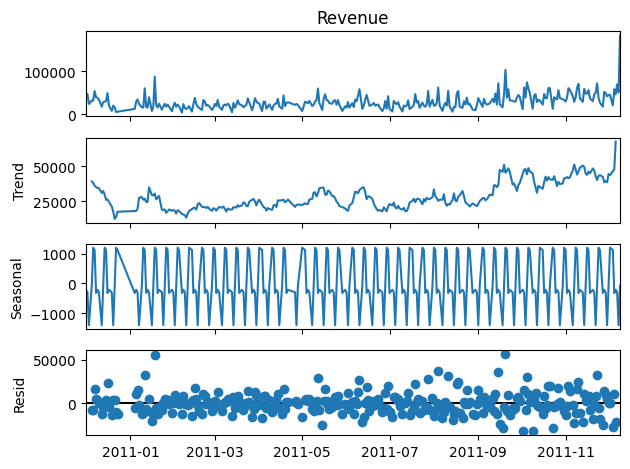

In [2]:
# Decomposition
decomp = seasonal_decompose(daily['Revenue'], model='additive', period=7)
decomp.plot()
plt.tight_layout()
plt.show()

In [3]:
# Prepare Prophet format (needs ds, y columns)
prophet_df = daily.reset_index()[['Date','Revenue']].rename(columns={'Date':'ds','Revenue':'y'})
prophet_df.to_csv('../data/prophet_input.csv', index=False)
prophet_df.tail()

,ds,y
300,2011-12-05,58202.21
301,2011-12-06,46144.04
302,2011-12-07,69354.21
303,2011-12-08,50519.41
304,2011-12-09,184349.28
